Projet OC n°7 : Réalisez une analyse de sentiments grâce au Deep Learning
=========================================================================

In [ ]:
import pandas as pd


In [56]:
import os
import missingno as msno
import requests
import zipfile
import matplotlib.pyplot as plt
import chardet
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import re

I. Présentation générale du jeu de données
******************************************

In [ ]:
# Définition des colonnes
columns = ["target", "ids", "date", "flag", "user", "text"]
data = pd.read_csv(
    "../data/raw/training.1600000.processed.noemoticon.csv",
    encoding="utf-8",
    encoding_errors="ignore",  # ignore caractere no decodable
    names=columns,
)
# Identification des sentiments 
data["target"] = data["target"].map({0: 0, 4: 1})
# Création d'une colonne pour le sentiment
data["sentiment"] = [
    "Negatif" if x == 0 else "Positif" for x in data["target"]
]
data.head()

,target,ids,date,flag,user,text,sentiment
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",Negatif
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,Negatif
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,Negatif
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,Negatif
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",Negatif


In [58]:
# Récupération des dimensions du DataFrame
datas = data.shape
columns = datas[1]
rows = datas[0]

# Comptage des types de données
data_type = data.dtypes.value_counts()
var_qual = data_type.iloc[1]
var_quant = data_type.iloc[0]

# Calcul du nombre total de valeurs
values = data.size

# Affichage des informations importantes
print("\033[1m" + "\033[91m" + "Informations importantes :" + "\033[0m" + "\n")
print(f"Total colonnes : {columns} variables.\n")
print(f"    -> {var_qual} variables qualitatives.")
print(f"    -> {var_quant} variables quantitatives.")
print(f"\nTotal lignes : {rows} individus.")
print(f"\nTotal : {values} valeurs.")

Informations importantes :

Total colonnes : 7 variables.

    -> 2 variables qualitatives.
    -> 5 variables quantitatives.

Total lignes : 1600000 individus.

Total : 11200000 valeurs.


target       0
ids          0
date         0
flag         0
user         0
text         0
sentiment    0
dtype: int64

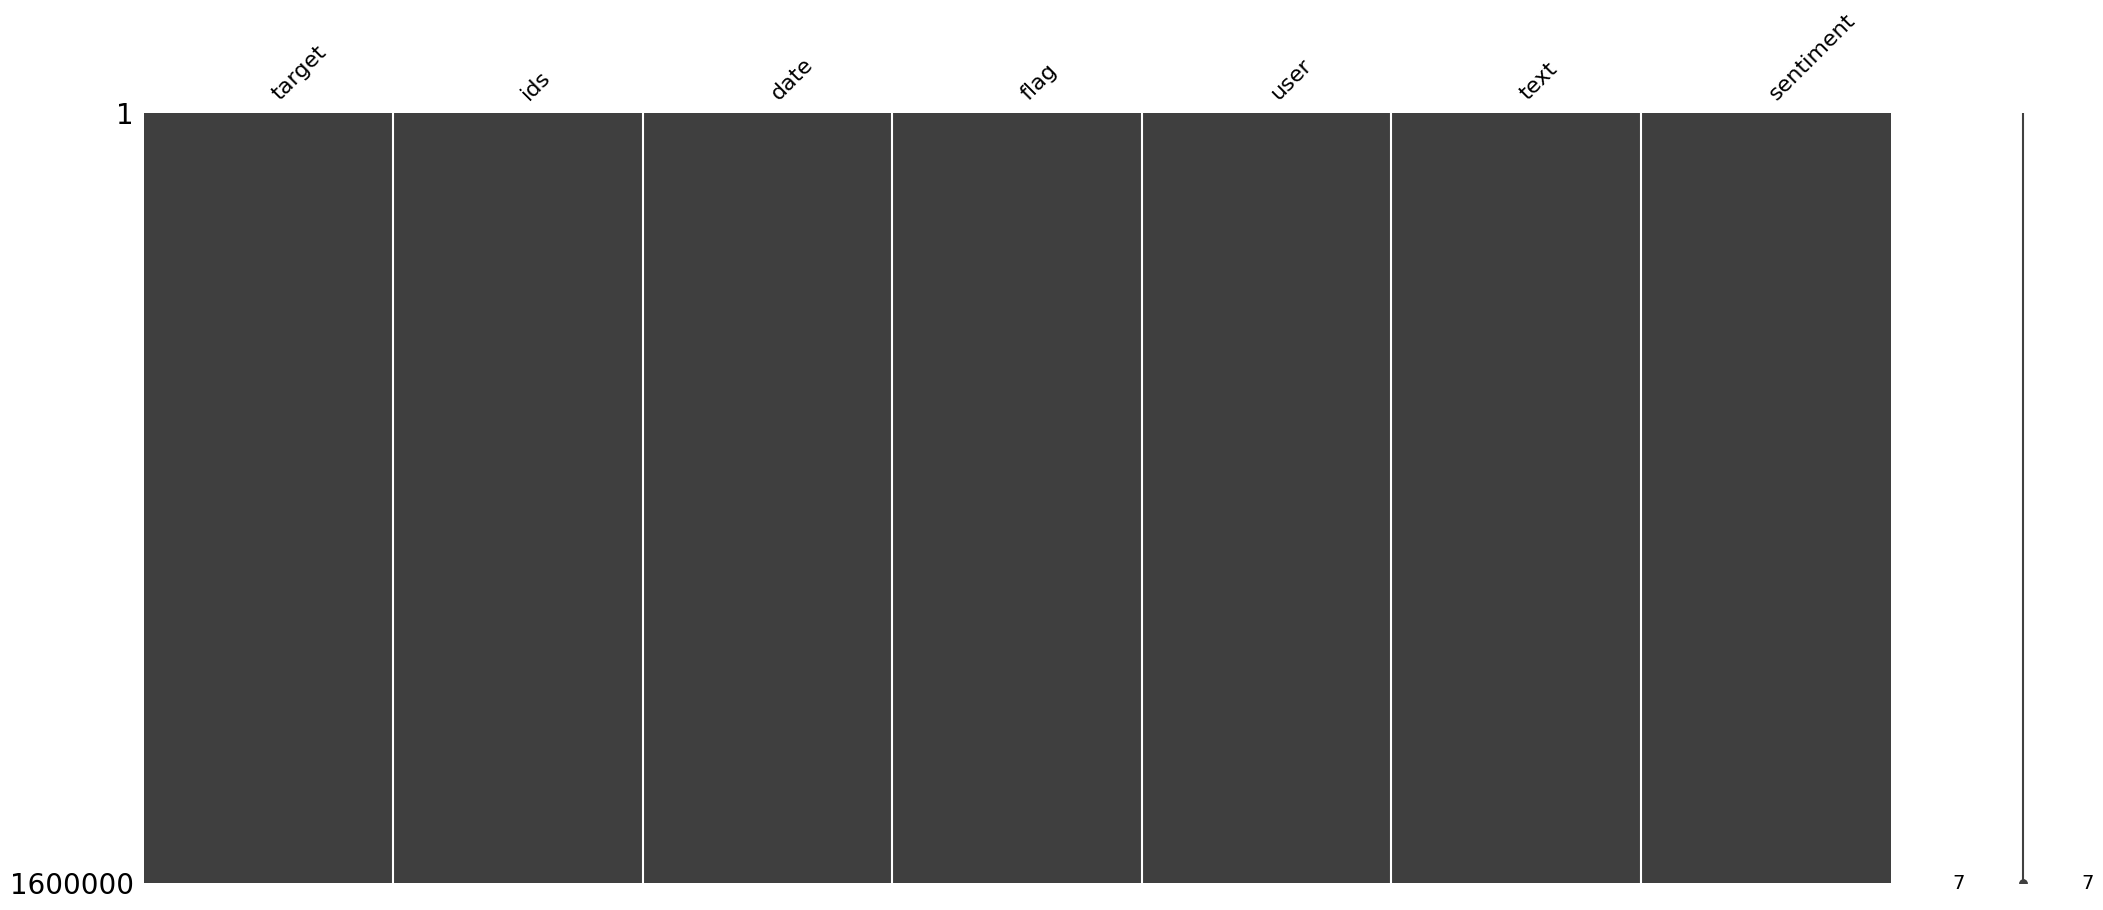

In [59]:
# Afficher la matrice des données manquantes
msno.matrix(data)
data.isnull().sum()

II. Exploration et nettoyage des données
****************************************

/var/folders/q1/yy2wcr4j61g8k3kwf0r74nnh0000gn/T/ipykernel_49476/979003502.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


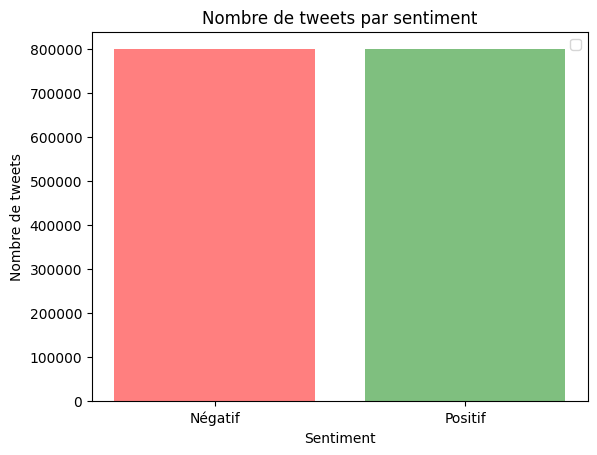

In [60]:
# Identifier les sentiment positifs et négatifs
negatif_count = data[data["target"] == 0].shape[0]
positif_count = data[data["target"] == 1].shape[0]

categories = ["Négatif", "Positif"]
counts = [negatif_count, positif_count]
colors = ["red", "green"]

plt.bar(categories, counts, color=colors, alpha=0.5)
plt.title("Nombre de tweets par sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Nombre de tweets")
plt.legend()
plt.show()

In [ ]:
# Calculer le nombre de mots dans chaque tweet
number_of_tweet = len(data["text"])
data_lens = data["text"].str.len()

total_word_data, data_min, data_max = (
    data_lens.sum(),
    data_lens.min(),
    data_lens.max(),
)


print(
    f"{'-' * 50} \n Nombre total de tweets: {number_of_tweet}\n Nombre de mots tous les tweets : {total_word_data}\n Nombre de mots mininum dans un tweet : {data_min}\n Nombre de mots maximum dans un tweet : {data_max}\n{'-' * 50} \n"
)

-------------------------------------------------- 
 Nombre total de tweets: 1600000
 Nombre de mots tous les tweets : 118461232
 Nombre de mots mininum dans un tweet : 6
 Nombre de mots maximum dans un tweet : 235
-------------------------------------------------- 



Le nombre moyen de mots par tweet est 13.18


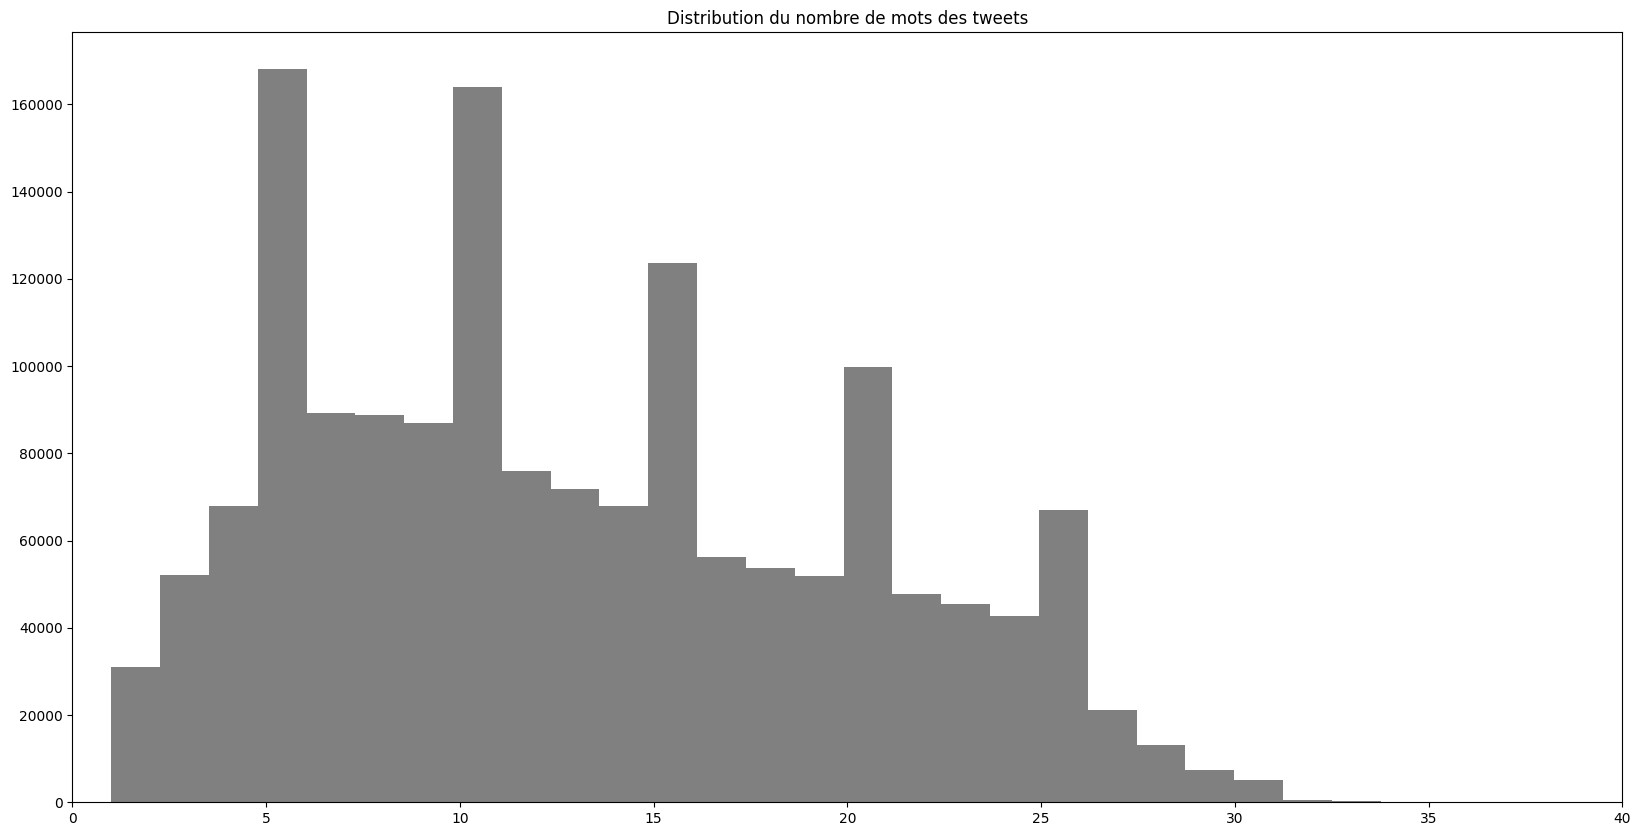

In [62]:
# Calculer le nombre de mots dans chaque tweet
data['word_count'] = data['text'].apply(lambda x: len(x.split()))

# Calculer le nombre moyen de mots
average_word_count = data['word_count'].mean()

print(f"Le nombre moyen de mots par tweet est {average_word_count:.2f}")

# Visualiser la distribution du nombre de mots
plt.figure(figsize=(20,10))
plt.hist(data['word_count'].values, bins=50, color="grey")
plt.title("Distribution du nombre de mots des tweets")
plt.xlim(0, 40)
plt.show()

In [ ]:
# Nettoyage des textes
def clean_text(text):
    text = text.lower()                                                     # Mettre en minuscule
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE) # Supprimer les liens
    text = re.sub(r'\@\w+|\#', '', text)                                    # Supprimer les pesudo-noms et les hashtags
    text = re.sub(r"[^\w\s]", "", text)                                     # Supprimer la ponctuation
    return text

data["cleaned_text"] = data["text"].apply(clean_text)

# Afficher un aperçu
data.head()

,target,ids,date,flag,user,text,sentiment,word_count,cleaned_text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",Negatif,19,a thats a bummer you shoulda got david car...
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,Negatif,21,is upset that he cant update his facebook by t...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,Negatif,18,i dived many times for the ball managed to sa...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,Negatif,10,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",Negatif,21,no its not behaving at all im mad why am i he...


In [ ]:
# Afficher les lignes vides
empty_text = data[
    data["cleaned_text"].isnull() | (data["cleaned_text"] == "")
]
print(f"Lignes vides :\n{empty_text}")

Lignes vides :
Empty DataFrame
Columns: [target, ids, date, flag, user, text, sentiment, word_count, cleaned_text]
Index: []


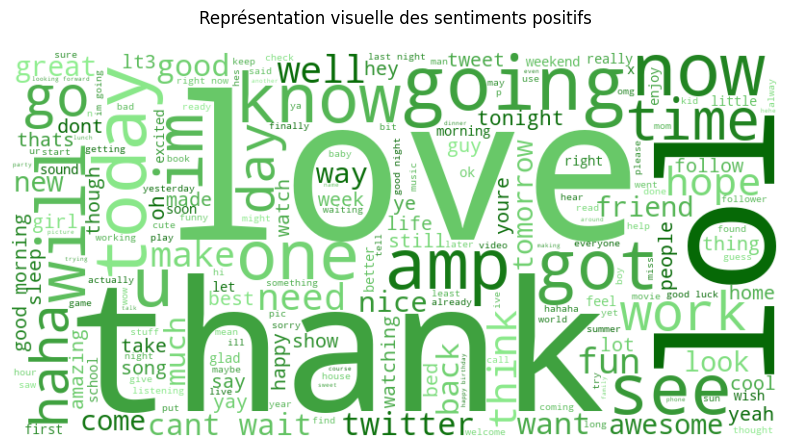

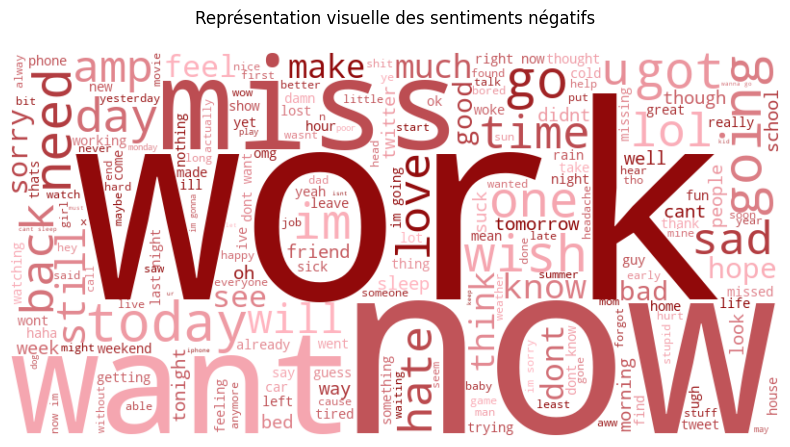

In [65]:
# Séparer les textes par sentiment
positive_text = " ".join(data[data["target"] == 1]["cleaned_text"])
negative_text = " ".join(data[data["target"] == 0]["cleaned_text"])

# Définition des palettes de couleurs
positive_colormap = mcolors.LinearSegmentedColormap.from_list("", ["#90EE90", "#006400"])  # Dégradé de vert clair à vert foncé
negative_colormap = mcolors.LinearSegmentedColormap.from_list("", ["#FFB6C1", "#8B0000"])  # Dégradé de rouge clair à rouge foncé

# Générer le nuage de mots pour les sentiments positifs
wordcloud_positive = WordCloud(
    width=800, 
    height=400, 
    background_color="white",
    colormap=positive_colormap
).generate(positive_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("Représentation visuelle des sentiments positifs", pad=20)
plt.show()

# Générer le nuage de mots pour les sentiments négatifs
wordcloud_negative = WordCloud(
    width=800, 
    height=400, 
    background_color="white",
    colormap=negative_colormap
).generate(negative_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("Représentation visuelle des sentiments négatifs", pad=20)
plt.show()

In [68]:
data.to_csv(
    "../data/processed/cleaned_dataset_sentiment.csv", index=False, encoding="utf-8"
)

In [67]:
from sklearn.model_selection import train_test_split

# Séparation des features et labels
X = df["text_clean"]
y = df["target"]

# Division en Train (70%), Validation (15%), Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

ModuleNotFoundError: No module named 'sklearn'

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)  # Utiliser 5000 mots les plus fréquents

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import mlflow

# Début de l'expérimentation MLflow
mlflow.set_experiment("Sentiment Analysis")

with mlflow.start_run():
    # Définition du modèle
    model = LogisticRegression()

    # Entraînement du modèle
    model.fit(X_train_tfidf, y_train)

    # Évaluation
    val_acc = accuracy_score(y_val, model.predict(X_val_tfidf))
    test_acc = accuracy_score(y_test, model.predict(X_test_tfidf))

    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    # Enregistrement des métriques
    mlflow.log_metric("validation_accuracy", val_acc)
    mlflow.log_metric("test_accuracy", test_acc)

    # Enregistrement du modèle
    mlflow.sklearn.log_model(model, "logistic_regression_model")

/Users/laureendademeule/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
2025/03/07 14:53:28 INFO mlflow.tracking.fluent: Experiment with name 'Sentiment Analysis' does not exist. Creating a new experiment.


Validation Accuracy: 0.7903
Test Accuracy: 0.7903


2025/03/07 14:53:30 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /var/folders/q1/yy2wcr4j61g8k3kwf0r74nnh0000gn/T/tmpt0es4cim/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.6.0', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 
2025/03/07 14:53:31 WARNING mlflow.utils.requirements_utils: Encountered an unexpected error (PermissionError(13, 'Permission denied')) while detecting model dependency mismatches. Set logging level to DEBUG to see the full traceback.
2025/03/07 14:53:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
